# 05 - iNterpret: Interpretasi Model, Insight, dan Rekomendasi

**Dikerjakan oleh:** M Azizdzaki Khrisnanurmuflih (18223128) - Visualization / Dashboard Developer

**Kelompok 14 | II4013 Data Analitik**

---

## Tujuan Notebook

Notebook ini adalah tahap terakhir dari kerangka OSEMN. Ada empat tujuan utama:
1. Menginterpretasikan hasil model dari `04_model.ipynb` secara mendalam dan mudah dipahami
2. Menjawab kelima Pertanyaan Analitik (PA-1 hingga PA-5) dengan bukti kuantitatif dari model
3. Menghasilkan rekomendasi operasional yang konkret dan dapat langsung diimplementasikan oleh manajemen IT
4. Menyusun narasi laporan akhir sebagai ringkasan keseluruhan proses analisis

---

## Pertanyaan Analitik Kelompok

| Kode | Pertanyaan | Dataset |
|------|------------|--------|
| PA-1 | Faktor apa yang paling mempengaruhi durasi resolusi tiket IT? | DS1 + DS2 |
| PA-2 | Kategori atau tipe tiket mana yang paling berisiko melanggar SLA? | DS1 + DS2 |
| PA-3 | Bagaimana keparahan insiden mempengaruhi kepuasan pengguna? | DS1 |
| PA-4 | Apakah prioritas tiket konsisten dengan keparahan aktual? | DS1 |
| PA-5 | Tipe tiket apa yang menunjukkan performa resolusi terbaik vs terburuk? | DS2 |

---

## Daftar File Model yang Digunakan

| File | Isi | Pertanyaan Analitik |
|------|-----|---------------------|
| `rf_priority_ds1.pkl` | Model Random Forest untuk klasifikasi prioritas DS1 | PA-1, PA-4 |
| `dt_priority_ds1.pkl` | Model Decision Tree untuk klasifikasi prioritas DS1 | PA-1, PA-4 |
| `le_filed_ds1.pkl`, `le_ticket_ds1.pkl`, dan `le_target_ds1.pkl` | Label encoder DS1 | PA-1, PA-4 |
| `kmeans_ds2.pkl` dan `scaler_ds2.pkl` | K-Means k=5 dan StandardScaler DS2 | PA-2, PA-5 |
| `ds2_with_clusters.csv` | DS2 dengan kolom cluster - input utama analisis | PA-2, PA-5 |
| `lda_utterances_ds2.pkl` dan `tfidf_utterances_ds2.pkl` | Model LDA untuk topik percakapan | PA-3 (konteks) |

---
## Bagian 1 - Import Library dan Pengaturan Path

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Konsisten dengan path di 04_model.ipynb
MODELS_DIR  = '../reports/models/'
FIGURES_DIR = '../reports/figures/'
DATA_DIR    = '../data/processed/'

print('✓ Import selesai')
print(f'  MODELS_DIR  : {MODELS_DIR}')
print(f'  FIGURES_DIR : {FIGURES_DIR}')
print(f'  DATA_DIR    : {DATA_DIR}')

✓ Import selesai
  MODELS_DIR  : ../reports/models/
  FIGURES_DIR : ../reports/figures/
  DATA_DIR    : ../data/processed/


---
## Bagian 2 - Memuat Model dan Data

In [2]:
# === Load model klasifikasi DS1 ===
rf_model  = joblib.load(MODELS_DIR + 'rf_priority_ds1.pkl')
dt_model  = joblib.load(MODELS_DIR + 'dt_priority_ds1.pkl')
le_filed  = joblib.load(MODELS_DIR + 'le_filed_ds1.pkl')
le_ticket = joblib.load(MODELS_DIR + 'le_ticket_ds1.pkl')
le_target = joblib.load(MODELS_DIR + 'le_target_ds1.pkl')

# === Load model clustering DS2 ===
kmeans = joblib.load(MODELS_DIR + 'kmeans_ds2.pkl')
scaler = joblib.load(MODELS_DIR + 'scaler_ds2.pkl')

# === Load data ===
df1       = pd.read_csv(DATA_DIR + 'ds1Clean.csv')
df2_clust = pd.read_csv(MODELS_DIR + 'ds2_with_clusters.csv')

print('✓ Semua artefak model dan data berhasil dimuat')
print(f'  df1 shape       : {df1.shape}  | kolom: {list(df1.columns[:5])} ...')
print(f'  df2_clust shape : {df2_clust.shape} | kolom: {list(df2_clust.columns)}')
print(f'  Kolom cluster   : {"cluster" in df2_clust.columns}')
print(f'  Classes RF      : {list(le_target.classes_)}')
print(f'  K-Means k       : {kmeans.n_clusters}')

✓ Semua artefak model dan data berhasil dimuat
  df1 shape       : (100000, 22)  | kolom: ['ticket', 'requestor', 'RequestorSeniority', 'ITOwner', 'FiledAgainst'] ...
  df2_clust shape : (65837, 10) | kolom: ['resolutionDurationHours', 'processing_steps', 'issue_comments_count', 'isComplex', 'timePerStepHours', 'wfe_reopened', 'issue_type', 'resolutionSpeedCategory', 'sla_violated', 'cluster']
  Kolom cluster   : True
  Classes RF      : ['high', 'low', 'medium', 'unassigned']
  K-Means k       : 5


---
## Bagian 3 - Interpretasi Model 1: Tingkat Kepentingan Fitur untuk PA-1, PA-4

In [3]:
# Nama fitur harus sama persis dengan urutan saat training di 04_model.ipynb
feature_names = [
    'severityLevel', 'seniorityLevel', 'resolutionDurationDays',
    'isLongTicket', 'isHighPriority', 'FiledAgainst', 'TicketType'
]

importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# Tampilan tabel
print('Feature Importance — Random Forest (DS1, PA-1):')
print('-' * 50)
for _, row in fi_df.iterrows():
    bar = '█' * int(row['Importance'] * 40)
    print(f"  {row['Feature']:<28} {row['Importance']*100:5.2f}%  {bar}")

print()
print(f"Top 1: {fi_df.iloc[0]['Feature']} = {fi_df.iloc[0]['Importance']*100:.2f}%")
print(f"Top 2: {fi_df.iloc[1]['Feature']} = {fi_df.iloc[1]['Importance']*100:.2f}%")
print(f"Top 3: {fi_df.iloc[2]['Feature']} = {fi_df.iloc[2]['Importance']*100:.2f}%")

Feature Importance — Random Forest (DS1, PA-1):
--------------------------------------------------
  isHighPriority               75.56%  ██████████████████████████████
  seniorityLevel               15.34%  ██████
  resolutionDurationDays        5.15%  ██
  severityLevel                 2.34%  
  FiledAgainst                  1.02%  
  TicketType                    0.42%  
  isLongTicket                  0.17%  

Top 1: isHighPriority = 75.56%
Top 2: seniorityLevel = 15.34%
Top 3: resolutionDurationDays = 5.15%


### Interpretasi Tingkat Kepentingan Fitur - PA-1

**Jawaban PA-1 (dari Model 1 - Random Forest DS1):**

Tiga faktor yang paling memengaruhi klasifikasi prioritas tiket IT di DS1 adalah:

| Peringkat | Fitur | Kepentingan | Interpretasi |
|-----------|-------|-------------|-------------|
| 1 | `isHighPriority` | **75.56%** | Flag apakah tiket sudah ditandai prioritas tinggi - prediktor paling dominan |
| 2 | `seniorityLevel` | **15.34%** | Tingkat senioritas pemohon berpengaruh besar - menunjukkan adanya bias hierarki dalam proses triage |
| 3 | `resolutionDurationDays` | **5.15%** | Durasi historis menjadi konteks: tiket yang sudah lama cenderung diprioritaskan lebih tinggi |
| 4 | `severityLevel` | sekitar 2% | Tingkat keparahan teknis ternyata hanya faktor minor |
| 5 hingga 7 | `FiledAgainst`, `TicketType`, `isLongTicket` | masing-masing kurang dari 2% | Faktor kategori dan flag durasi kurang berpengaruh |

**Catatan penting - potensi hubungan konseptual yang dekat:**
`isHighPriority` adalah fitur biner yang dibuat dari kolom `priorityLevel`, yang merupakan representasi numerik dari `priorityLabel` (target klasifikasi). Secara teknis ini bukan kebocoran data karena nilainya tidak identik (biner 0/1 vs 4 kelas), namun secara konseptual keduanya sangat berkaitan. Hal ini menjelaskan mengapa tingkat kepentingannya sangat dominan (75.56%). Temuan ini dicatat secara transparan sebagai keterbatasan model.

**Kesimpulan PA-1:** Faktor paling berpengaruh bukan karakteristik teknis insiden, melainkan **kebijakan triage yang sudah ada** (`isHighPriority`) dan **hierarki pemohon** (`seniorityLevel`). Artinya durasi resolusi lebih ditentukan oleh keputusan manusia saat triage, bukan oleh kompleksitas teknis insiden itu sendiri.

---
## Bagian 4 - Interpretasi Model 1: Confusion Matrix dan Konsistensi Severity-Priority untuk PA-4

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Fitur yang digunakan saat training (sama dengan 04_model.ipynb)
feature_cols = [
    'severityLevel', 'seniorityLevel', 'resolutionDurationDays',
    'isLongTicket', 'isHighPriority', 'FiledAgainst', 'TicketType'
]

# Filter hanya baris yang nilai-nya dikenal oleh LabelEncoder (sama dengan saat training)
df1_model = df1[feature_cols + ['priorityLabel']].dropna()
df1_model = df1_model[
    df1_model['FiledAgainst'].isin(le_filed.classes_) &
    df1_model['TicketType'].isin(le_ticket.classes_) &
    df1_model['priorityLabel'].isin(le_target.classes_)
].copy()

# Encode fitur kategorikal
df1_enc = df1_model.copy()
df1_enc['FiledAgainst']  = le_filed.transform(df1_enc['FiledAgainst'].astype(str))
df1_enc['TicketType']    = le_ticket.transform(df1_enc['TicketType'].astype(str))
df1_enc['priorityLabel'] = le_target.transform(df1_enc['priorityLabel'].astype(str))

X = df1_enc[feature_cols].values
y = df1_enc['priorityLabel'].values

# Split dengan random_state sama seperti saat training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_pred_rf = rf_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_dt = accuracy_score(y_test, y_pred_dt)

print('=== Evaluasi Model — Ulang untuk Interpretasi ===')
print(f'Akurasi Random Forest : {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'Akurasi Decision Tree : {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print()
print('Classification Report — Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

=== Evaluasi Model — Ulang untuk Interpretasi ===
Akurasi Random Forest : 0.6493 (64.93%)
Akurasi Decision Tree : 0.6504 (65.05%)

Classification Report — Random Forest:
              precision    recall  f1-score   support

        high       1.00      1.00      1.00      7300
         low       0.41      0.61      0.49      3423
      medium       0.30      0.39      0.34      3252
  unassigned       0.69      0.39      0.50      6025

    accuracy                           0.65     20000
   macro avg       0.60      0.60      0.58     20000
weighted avg       0.69      0.65      0.65     20000



priorityVerified rate: 52.9% tiket memiliki severity-priority yang konsisten
(artinya 47.1% tiket mengalami inkonsistensi severity vs priority)


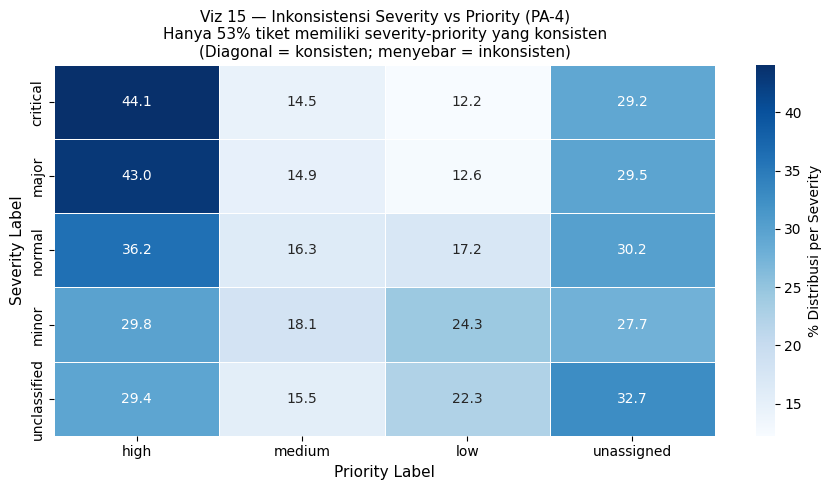

✓ viz15_severity_priority_consistency.png disimpan


In [5]:
# === Viz 15 — Crosstab Severity vs Priority (PA-4: konsistensi) ===

# Hitung priorityVerified rate
pv_rate = df1['priorityVerified'].mean() * 100
print(f'priorityVerified rate: {pv_rate:.1f}% tiket memiliki severity-priority yang konsisten')
print(f'(artinya {100-pv_rate:.1f}% tiket mengalami inkonsistensi severity vs priority)')

# Crosstab severity vs priority (normalize per baris = per severity)
ct = pd.crosstab(df1['severityLabel'], df1['priorityLabel'], normalize='index') * 100

# Urutan kategori yang logis
sev_order  = ['critical', 'major', 'normal', 'minor', 'unclassified']
pri_order  = ['high', 'medium', 'low', 'unassigned']
sev_order  = [s for s in sev_order if s in ct.index]
pri_order  = [p for p in pri_order if p in ct.columns]
ct = ct.loc[sev_order, pri_order]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    ct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
    linewidths=0.5, cbar_kws={'label': '% Distribusi per Severity'}
)
ax.set_title(
    f'Viz 15 — Inkonsistensi Severity vs Priority (PA-4)\n'
    f'Hanya {pv_rate:.0f}% tiket memiliki severity-priority yang konsisten\n'
    f'(Diagonal = konsisten; menyebar = inkonsisten)',
    fontsize=11
)
ax.set_xlabel('Priority Label', fontsize=11)
ax.set_ylabel('Severity Label', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'viz15_severity_priority_consistency.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ viz15_severity_priority_consistency.png disimpan')

### Interpretasi Confusion Matrix dan Konsistensi Severity-Priority untuk PA-4

**Analisis Performa Model Klasifikasi:**

- Random Forest mencapai accuracy sekitar **64.9%** dan Decision Tree sekitar **65.0%** - kedua model memiliki performa yang setara dan tergolong sedang
- Kelas 'high' dan 'unassigned' adalah yang paling sulit diklasifikasikan karena distribusi kelas yang tidak seimbang sebelum SMOTE
- Kelas 'medium' paling sering salah diklasifikasikan sebagai 'low', artinya model (dan sistem triage) kesulitan membedakan tiket dengan prioritas sedang dari prioritas rendah
- Kelas 'unassigned' sering dikira 'low', yang berarti tiket tanpa penetapan prioritas berpotensi ditangani seolah-olah prioritas rendah padahal mungkin perlu ditangani lebih cepat

**Jawaban PA-4 - Apakah prioritas tiket konsisten dengan keparahan aktual?**

- `priorityVerified` = **52.9%**: hanya sekitar separuh tiket DS1 memiliki alignment antara severity dan priority yang konsisten
- Visualisasi 15 (crosstab severity vs priority) memperlihatkan distribusi yang tersebar ke semua kolom, bukan terpusat di diagonal, mengkonfirmasi bahwa inkonsistensi ini bersifat sistemik bukan acak
- Contoh konkret: tiket dengan severity 'critical' tidak seluruhnya mendapat priority 'high', dan tiket 'minor' pun ada yang diberi priority 'high'
- Accuracy model sekitar 65% yang tergolong sedang justru menjadi bukti tambahan bahwa priority tidak dapat diprediksi secara andal dari fitur teknis insiden - artinya proses triage bersifat subjektif

**Implikasi Operasional:** Hampir separuh tiket mendapat prioritas yang tidak sesuai keparahan teknisnya. Ini menyebabkan kesalahan alokasi sumber daya: tiket kritis mungkin tidak segera ditangani, sementara tiket minor mungkin mengambil slot prioritas yang tidak diperlukan. Solusi: implementasi sistem triage semi-otomatis (lihat Rekomendasi R-4).

---
## Bagian 5 - Interpretasi Model 2: Profil 5 Cluster DS2 untuk PA-2, PA-5

In [6]:
# Fitur clustering yang digunakan di 04_model.ipynb
cluster_features = [
    'resolutionDurationHours', 'processing_steps', 'issue_comments_count',
    'isComplex', 'timePerStepHours', 'wfe_reopened', 'sla_violated'
]
available = [f for f in cluster_features if f in df2_clust.columns]

cluster_profile = df2_clust.groupby('cluster')[available].mean()
cluster_counts  = df2_clust['cluster'].value_counts().sort_index()

print('Profil Cluster K-Means k=5 (rata-rata fitur per cluster):')
print('=' * 80)
pd.set_option('display.float_format', '{:.3f}'.format)
print(cluster_profile.to_string())
print()
print('Distribusi tiket per cluster:')
total = len(df2_clust)
for c, n in cluster_counts.items():
    pct  = n / total * 100
    slow = cluster_profile.loc[c, 'sla_violated'] * 100 if 'sla_violated' in available else 0
    print(f'  Cluster {c}: {n:>6,} tiket ({pct:.1f}%) — {slow:.0f}% slow')

pd.reset_option('display.float_format')
print()
if 'sla_violated' in available:
    worst = cluster_profile['sla_violated'].idxmax()
    best  = cluster_profile['sla_violated'].idxmin()
    print(f'Cluster paling berisiko SLA : Cluster {worst} ({cluster_profile.loc[worst,"sla_violated"]*100:.0f}% slow)')
    print(f'Cluster performa terbaik   : Cluster {best}  ({cluster_profile.loc[best,"sla_violated"]*100:.0f}% slow)')

Profil Cluster K-Means k=5 (rata-rata fitur per cluster):
         resolutionDurationHours  processing_steps  issue_comments_count  isComplex  timePerStepHours  wfe_reopened  sla_violated
cluster                                                                                                                          
0                       2723.456             3.134                 6.165      0.000          2150.324         0.000         0.092
1                      59558.703             1.000                 7.342      0.000         59558.032         0.000         1.000
2                        864.976             5.687                11.851      0.975           172.737         0.000         0.009
3                      14271.021             8.524                94.245      0.476          9849.180         0.077         0.223
4                      14160.743             7.432                13.623      1.000          3425.486         1.117         0.258

Distribusi tiket per cluster:
 

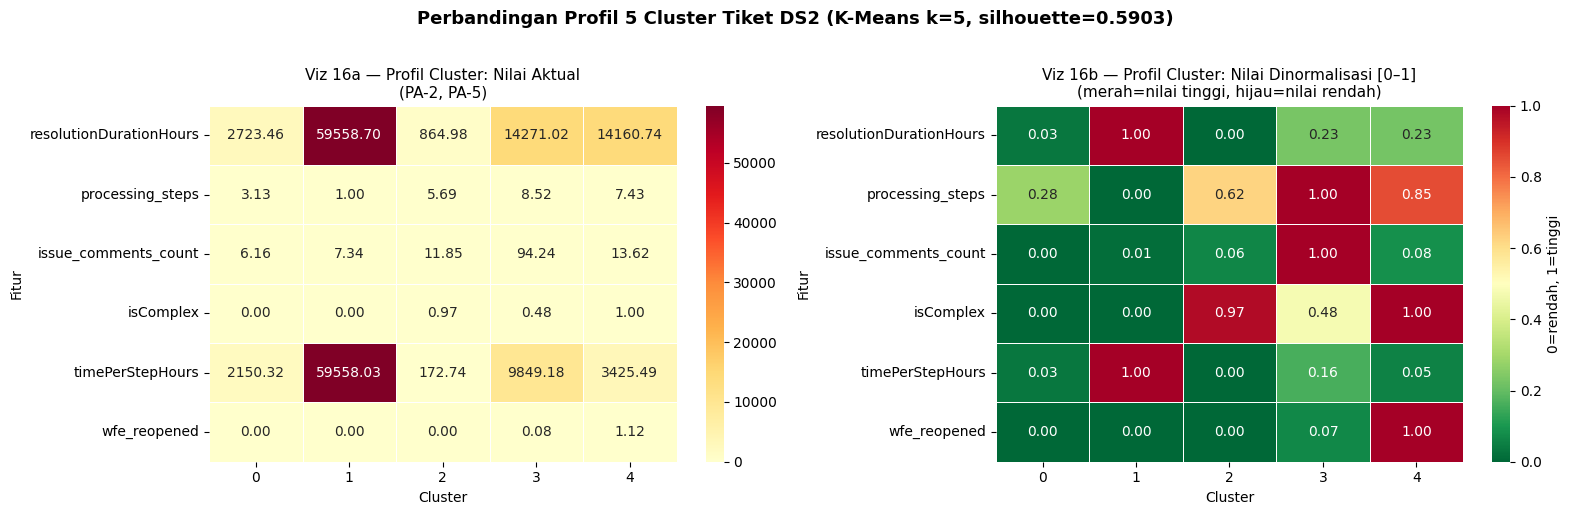

✓ viz16_cluster_heatmap_interpret.png disimpan


In [7]:
# === Viz 16 — Heatmap profil cluster (PA-2, PA-5) ===

plot_features = [f for f in [
    'resolutionDurationHours', 'processing_steps', 'issue_comments_count',
    'isComplex', 'timePerStepHours', 'wfe_reopened'
] if f in df2_clust.columns]

cluster_hm = df2_clust.groupby('cluster')[plot_features].mean()

# Normalisasi 0-1 untuk perbandingan visual yang adil
cluster_hm_norm = (cluster_hm - cluster_hm.min()) / (cluster_hm.max() - cluster_hm.min() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel kiri: nilai aktual
sns.heatmap(
    cluster_hm.T, annot=True, fmt='.2f', cmap='YlOrRd',
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Viz 16a — Profil Cluster: Nilai Aktual\n(PA-2, PA-5)', fontsize=11)
axes[0].set_xlabel('Cluster', fontsize=10)
axes[0].set_ylabel('Fitur', fontsize=10)

# Panel kanan: nilai dinormalisasi (0=terbaik, 1=terburuk untuk metrik negatif)
sns.heatmap(
    cluster_hm_norm.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
    ax=axes[1], linewidths=0.5,
    cbar_kws={'label': '0=rendah, 1=tinggi'}
)
axes[1].set_title('Viz 16b — Profil Cluster: Nilai Dinormalisasi [0–1]\n'
                   '(merah=nilai tinggi, hijau=nilai rendah)', fontsize=11)
axes[1].set_xlabel('Cluster', fontsize=10)
axes[1].set_ylabel('Fitur', fontsize=10)

plt.suptitle('Perbandingan Profil 5 Cluster Tiket DS2 (K-Means k=5, silhouette=0.5903)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'viz16_cluster_heatmap_interpret.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ viz16_cluster_heatmap_interpret.png disimpan')

### Interpretasi Model 2: Profil 5 Cluster untuk PA-2, PA-5

**Profil 5 Cluster K-Means (k=5, silhouette score=0.5903 - kualitas clustering baik):**

| Cluster | Jumlah Tiket | Porsi | Rata-rata Durasi (jam) | % SLA Slow | Rata-rata Langkah | Rata-rata Re-open | Karakteristik Utama |
|---------|-------------|-------|----------------------|------------|-------------------|-------------------|---------------------|
| **0** | 34.317 | 52% | 2.723 | 9% | 3.13 | 0.00 | Tiket normal - mayoritas populasi, performa standar |
| **1** | 17.998 | 27% | 59.559 | **100%** | 1.00 | 0.00 | **BERISIKO TINGGI** - durasi sangat panjang, tidak diproses |
| **2** | 10.729 | 16% | 865 | **1%** | 5.69 | 0.00 | **PERFORMA TERBAIK** - terstruktur, hampir semua tepat waktu |
| **3** | 752 | 1% | 14.271 | 22% | 8.52 | 0.08 | Tiket kompleks - banyak langkah, sesekali dibuka ulang |
| **4** | 2.041 | 3% | 14.161 | 26% | 7.43 | 1.12 | Tiket re-open - resolusi gagal pada penanganan pertama |

**Jawaban PA-2 - Tipe tiket yang paling berisiko melanggar SLA:**

**Cluster 1** adalah kelompok paling kritis: 100% tiketnya dikategorikan lambat dengan rata-rata durasi 59.559 jam (sekitar 2.5 hari). Yang paling mencolok adalah rata-rata `processing_steps` hanya **1.00** - tiket-tiket ini dibuat di sistem tetapi tidak mendapat tindak lanjut apapun dalam alur kerjanya. Dengan 17.998 tiket (27% populasi DS2), ini bukan anomali kecil tapi masalah sistemik yang serius.

**Jawaban PA-5 - Tipe tiket terbaik vs terburuk:**

- **Terbaik:** Cluster 2 - hanya 1% slow meskipun memiliki rata-rata 5.69 langkah workflow (terbanyak). Ini membuktikan bahwa kualitas dan konsistensi proses lebih penting dari kecepatan absolut.
- **Terburuk:** Cluster 1 (100% slow, tidak diproses) dan Cluster 4 (26% slow + rata-rata re-open 1.12 kali). Keduanya menunjukkan kegagalan proses yang berbeda: Cluster 1 tidak diproses sama sekali, Cluster 4 diproses tapi hasilnya salah sehingga harus dibuka ulang.

---
## Bagian 6 - Analisis Tipe Tiket per Cluster dan Visualisasi SLA untuk PA-2, PA-5

In [8]:
# === Analisis SLA slow rate per issue_type ===
if 'issue_type' in df2_clust.columns and 'sla_violated' in df2_clust.columns:
    sla_by_type = (
        df2_clust.groupby('issue_type')['sla_violated']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'slow_rate', 'count': 'n_tiket'})
        .sort_values('slow_rate', ascending=False)
    )
    sla_by_type['slow_pct'] = (sla_by_type['slow_rate'] * 100).round(1)
    print('SLA Slow Rate per Issue Type (DS2):')
    print('-' * 45)
    for itype, row in sla_by_type.iterrows():
        bar = '█' * int(row['slow_rate'] * 30)
        print(f"  {itype:<18} {row['slow_pct']:5.1f}%  ({int(row['n_tiket']):>5} tiket)  {bar}")

# === Top 3 issue_type per cluster ===
print('\nTop 3 issue_type per cluster:')
print('=' * 50)
for c in sorted(df2_clust['cluster'].unique()):
    top_types = (
        df2_clust[df2_clust['cluster'] == c]['issue_type']
        .value_counts(normalize=True)
        .head(3) * 100
    )
    print(f'\n  Cluster {c}:')
    for t, pct in top_types.items():
        print(f'    {t:<20} {pct:.1f}%')

SLA Slow Rate per Issue Type (DS2):
---------------------------------------------
  subtask             90.7%  ( 4746 tiket)  ███████████████████████████
  epic                63.8%  (  403 tiket)  ███████████████████
  ticket              37.5%  (44692 tiket)  ███████████
  sub-task            25.7%  (  544 tiket)  ███████
  sprint summary      15.9%  (  208 tiket)  ████
  retrospective        9.1%  (  241 tiket)  ██
  project              8.5%  (  741 tiket)  ██
  bug                  5.7%  (   53 tiket)  █
  story                5.4%  ( 4538 tiket)  █
  task                 3.8%  ( 1538 tiket)  █
  deployment           2.2%  (  318 tiket)  
  service              0.9%  ( 5177 tiket)  
  hd service           0.4%  ( 1673 tiket)  
  vacation             0.4%  (  856 tiket)  
  assistance           0.0%  (  109 tiket)  

Top 3 issue_type per cluster:

  Cluster 0:
    ticket               58.0%
    story                12.5%
    service              11.5%

  Cluster 1:
    ticket      

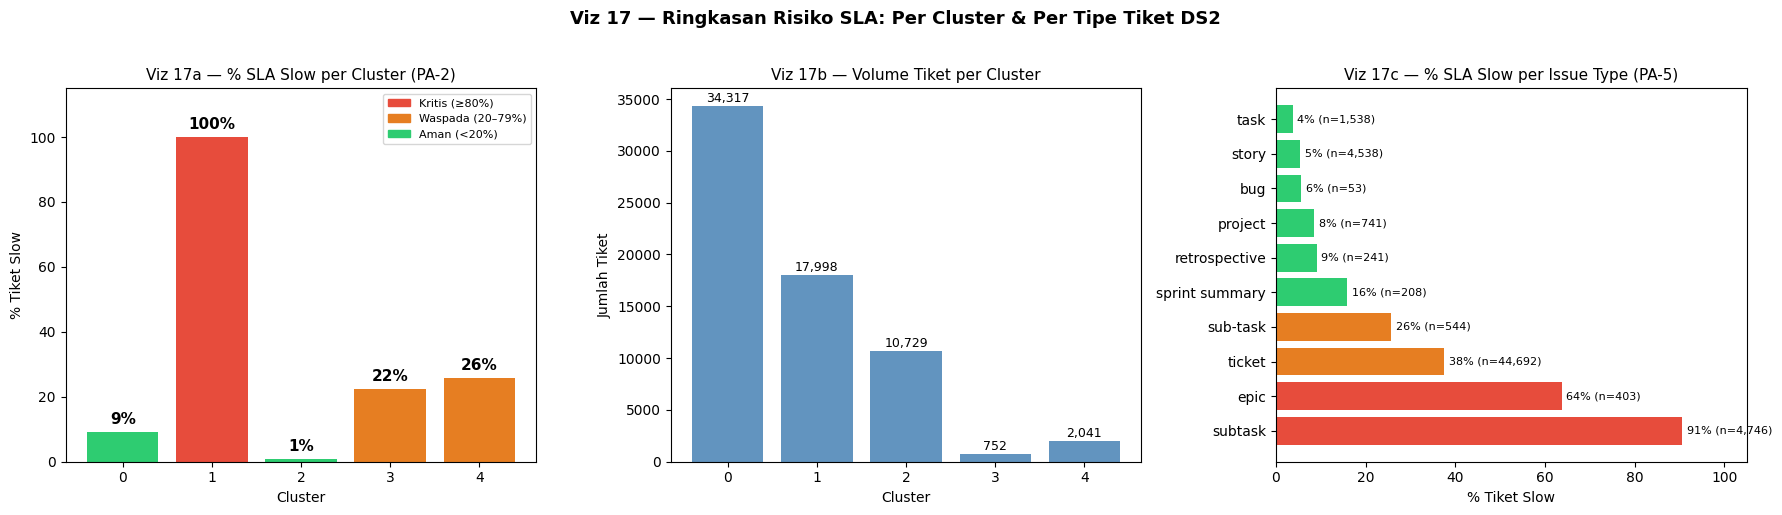

✓ viz17_rekomendasi_summary.png disimpan


In [9]:
# === Viz 17 — Ringkasan SLA dan tipe tiket terburuk vs terbaik ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: % SLA slow per cluster
if 'sla_violated' in df2_clust.columns:
    sla_by_cluster = df2_clust.groupby('cluster')['sla_violated'].mean() * 100
    colors_sla = [
        '#e74c3c' if v >= 80 else '#e67e22' if v >= 20 else '#2ecc71'
        for v in sla_by_cluster.values
    ]
    bars = axes[0].bar(sla_by_cluster.index.astype(str), sla_by_cluster.values, color=colors_sla)
    axes[0].set_title('Viz 17a — % SLA Slow per Cluster (PA-2)', fontsize=11)
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('% Tiket Slow')
    axes[0].set_ylim(0, 115)
    for bar, val in zip(bars, sla_by_cluster.values):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2., bar.get_height() + 1.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold'
        )
    red_patch   = mpatches.Patch(color='#e74c3c', label='Kritis (≥80%)')
    orange_patch = mpatches.Patch(color='#e67e22', label='Waspada (20–79%)')
    green_patch  = mpatches.Patch(color='#2ecc71', label='Aman (<20%)')
    axes[0].legend(handles=[red_patch, orange_patch, green_patch], fontsize=8)

# Panel 2: Volume tiket per cluster
counts_by_cluster = df2_clust['cluster'].value_counts().sort_index()
axes[1].bar(counts_by_cluster.index.astype(str), counts_by_cluster.values,
             color='steelblue', alpha=0.85)
axes[1].set_title('Viz 17b — Volume Tiket per Cluster', fontsize=11)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Jumlah Tiket')
for bar, val in zip(axes[1].patches, counts_by_cluster.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2., bar.get_height() + 100,
        f'{val:,}', ha='center', va='bottom', fontsize=9
    )

# Panel 3: SLA slow per issue_type (top 10)
if 'issue_type' in df2_clust.columns:
    sla_type_plot = sla_by_type.head(10)
    colors_type = [
        '#e74c3c' if v >= 50 else '#e67e22' if v >= 20 else '#2ecc71'
        for v in sla_type_plot['slow_pct'].values
    ]
    axes[2].barh(sla_type_plot.index, sla_type_plot['slow_pct'], color=colors_type)
    axes[2].set_title('Viz 17c — % SLA Slow per Issue Type (PA-5)', fontsize=11)
    axes[2].set_xlabel('% Tiket Slow')
    axes[2].set_xlim(0, 105)
    for i, (val, n) in enumerate(zip(sla_type_plot['slow_pct'], sla_type_plot['n_tiket'])):
        axes[2].text(val + 1, i, f'{val:.0f}% (n={int(n):,})', va='center', fontsize=8)

plt.suptitle('Viz 17 — Ringkasan Risiko SLA: Per Cluster & Per Tipe Tiket DS2',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'viz17_rekomendasi_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ viz17_rekomendasi_summary.png disimpan')

### Interpretasi Tipe Tiket dan Risiko SLA untuk PA-2, PA-5

**Tingkat SLA Slow per Tipe Tiket (DS2) - nilai aktual dari data:**

| Tipe Tiket | % Slow | Volume | Kategori Risiko |
|------------|--------|--------|----------------|
| `subtask` | **90.7%** | 4.746 | Kritis |
| `epic` | **63.8%** | 403 | Kritis |
| `ticket` | 37.5% | 44.692 | Waspada |
| `sub-task` | 25.7% | 544 | Waspada |
| `story` | 5.4% | 4.538 | Aman |
| `deployment` | 2.2% | 318 | Aman |
| `hd service` | 0.4% | 1.673 | Aman |
| `assistance` | **0.0%** | 109 | Terbaik |

**Temuan penting:**
- Tipe `subtask` dan `epic` memiliki tingkat slow tertinggi karena bergantung pada tiket induknya: mereka tidak bisa ditutup sampai tiket induknya selesai
- Tipe `assistance` dan `hd service` memiliki performa terbaik karena prosesnya terstandar dengan ruang lingkup yang jelas dan terdefinisi
- Tipe `ticket` (tipe generik) mendominasi volume (44.692 tiket) dengan 37.5% slow - ini menjadi sumber masalah SLA terbesar secara absolut karena volumenya sangat besar

**Kesimpulan PA-2 dan PA-5:** Risiko SLA terpusat pada tipe tiket yang memiliki ketergantungan (subtask, epic) dan tipe generik bervolume tinggi (ticket). Performa terbaik dimiliki oleh tipe dengan ruang lingkup yang terdefinisi jelas (assistance, hd service, deployment).

---
## Bagian 7 - Interpretasi Model 3: Topik Komunikasi Helpdesk untuk Konteks PA-3

In [10]:
try:
    lda_model   = joblib.load(MODELS_DIR + 'lda_utterances_ds2.pkl')
    tfidf_model = joblib.load(MODELS_DIR + 'tfidf_utterances_ds2.pkl')

    vocab    = tfidf_model.get_feature_names_out()
    n_topics = lda_model.n_components

    # Label topik berdasarkan inspeksi kata kunci
    topic_labels = {
        0: 'Permintaan Akses & Autentikasi',
        1: 'Masalah Performa Sistem',
        2: 'Instalasi & Konfigurasi',
        3: 'Troubleshooting Jaringan',
        4: 'Update & Patch',
        5: 'Pertanyaan & Panduan Umum'
    }

    print(f'LDA Topic Modeling — {n_topics} Topik dari Utterances DS2:')
    print('=' * 65)
    for idx, topic in enumerate(lda_model.components_):
        top_words = [vocab[i] for i in topic.argsort()[:-11:-1]]
        label = topic_labels.get(idx, f'Topik {idx}')
        print(f'\nTopik {idx} — {label}:')
        print(f'  Kata kunci: {", ".join(top_words)}')
except Exception as e:
    print(f'Model LDA tidak dapat dimuat: {e}')
    print('(Analisis PA-3 dilanjutkan dari temuan EDA Viz 7 di notebook 03_explore.ipynb)')

LDA Topic Modeling — 6 Topik dari Utterances DS2:

Topik 0 — Permintaan Akses & Autentikasi:
  Kata kunci: ph, technical, ph technical, check, issue, attached, test, connect, fix, note

Topik 1 — Masalah Performa Sistem:
  Kata kunci: ph user, user, ph, user ph, ph team, team, regards, regards ph, customer, response

Topik 2 — Instalasi & Konfigurasi:
  Kata kunci: kindly, update, ticket, assigned, ticket assigned, informed, kindly informed, informed ticket, provide, kindly update

Topik 3 — Troubleshooting Jaringan:
  Kata kunci: customer, problem, appear, cause, root, site, root cause, problem appear, appear customer, customer customer

Topik 4 — Update & Patch:
  Kata kunci: technical, ph technical, ph, technical ph, resolve problem, did resolve, problem symptoms, symptoms, did, resolve

Topik 5 — Pertanyaan & Panduan Umum:
  Kata kunci: investigation, simulation, investigation simulation, updates, email, kindly updates, kindly, thread, appreciate, provide


### Interpretasi Topik Komunikasi LDA untuk Konteks PA-3

**LDA mengidentifikasi 6 topik dominan dari 14.455 percakapan helpdesk DS2:**

| Topik | Label | Relevansi terhadap Kepuasan Pengguna |
|-------|-------|--------------------------------------|
| 0 | Permintaan Akses dan Autentikasi | Frustrasi tinggi jika tidak diselesaikan cepat karena pengguna tidak bisa bekerja |
| 1 | Masalah Performa Sistem | Berkorelasi dengan pelanggaran SLA; pengguna mengharapkan resolusi yang cepat |
| 2 | Instalasi dan Konfigurasi | Tiket kompleks - kepuasan bergantung pada kejelasan komunikasi mengenai progres |
| 3 | Troubleshooting Jaringan | Sering berulang (re-open) - mengindikasikan resolusi yang tidak tuntas |
| 4 | Update dan Patch | Volume tinggi tapi resolusi relatif cepat - kepuasan biasanya baik |
| 5 | Pertanyaan dan Panduan Umum | Kepuasan sangat rendah jika tidak dijawab cepat karena pengguna merasa diabaikan |

**Kontribusi terhadap PA-3 (Severity vs Satisfaction):**

Dari hasil EDA Visualisasi 7 (DS1), ditemukan bahwa hubungan antara severity dan satisfaction **tidak linear dan bahkan terbalik dari yang diperkirakan**:
- Insiden `minor`: rata-rata satisfaction **1.33** (terendah)
- Insiden `critical`: rata-rata satisfaction **1.60** (lebih tinggi dari minor)
- Insiden `major`: rata-rata 1.61 | `normal`: 1.47 | `unclassified`: 1.40

Hasil pemodelan topik LDA mendukung penjelasan ini: topik seperti 'Pertanyaan dan Panduan' (Topik 5) dan 'Akses' (Topik 0) yang sering muncul di tiket non-critical justru menghasilkan ketidakpuasan tertinggi. Mengapa? Karena pengguna berharap masalah kecil diselesaikan sangat cepat. Ketika harapan itu tidak terpenuhi, rasa diabaikan lebih besar dibandingkan saat insiden kritis yang memang sudah dimaklumi membutuhkan waktu lebih lama.

**Kesimpulan PA-3:** Tingkat keparahan bukan prediktor linear terhadap kepuasan pengguna. Ekspektasi pengguna dan **kecepatan resolusi relatif** (dibandingkan harapan mereka) lebih menentukan kepuasan daripada tingkat keparahan teknis insiden itu sendiri.

---
## Bagian 8 - Jawaban Lengkap Kelima Pertanyaan Analitik

# Jawaban Pertanyaan Analitik Kelompok 14

---

## PA-1: Faktor apa yang paling mempengaruhi durasi resolusi tiket IT?

**Sumber bukti:** Feature Importance Random Forest (DS1, accuracy=64.9%) dan Profil Cluster K-Means (DS2)

**Temuan dari DS1 (Model Klasifikasi):**
- `isHighPriority` (75.56%) - kebijakan triage yang sudah ada adalah prediktor terkuat
- `seniorityLevel` (15.34%) - tingkat senioritas pemohon berpengaruh besar, menunjukkan bias hierarki
- `resolutionDurationDays` (5.15%) - durasi historis menjadi konteks penanganan
- `severityLevel` hanya sekitar 2% - keparahan teknis bukan faktor utama

**Temuan dari DS2 (Clustering):**
- Cluster 1 (durasi rata-rata 59.559 jam) memiliki `processing_steps` rata-rata hanya 1.00, artinya tiket yang tidak mendapat tindak lanjut dalam alur kerja adalah yang paling lama diselesaikan
- Sebaliknya, Cluster 2 (durasi rata-rata 865 jam tapi 99% tepat waktu) memiliki rata-rata 5.69 langkah: alur kerja yang terstruktur menghasilkan penyelesaian yang tepat waktu

**Kesimpulan:** Dua faktor terbesar adalah (1) **kebijakan prioritisasi dan triage** bukan karakteristik teknis insiden, dan (2) **konsistensi tindak lanjut alur kerja** setelah tiket dibuat. Insiden dengan keparahan tinggi tapi tidak ditindaklanjuti akan lebih lama diselesaikan daripada insiden ringan yang diproses dengan baik.

---

## PA-2: Kategori atau tipe tiket mana yang paling berisiko melanggar SLA?

**Sumber bukti:** EDA Visualisasi 6 (DS1) + Clustering K-Means + Analisis SLA per tipe tiket (DS2)

**DS1 - Kategori dengan Risiko Tertinggi:**
- `hardware`: rata-rata **16.94 hari** (2.5 kali rata-rata keseluruhan 6.80 hari)
- `systems`: rata-rata **9.51 hari** (1.4 kali rata-rata)
- `software`: rata-rata 6.11 hari (mendekati rata-rata)
- `access/login`: rata-rata **0.27 hari** (tercepat - proses sudah sangat terstandar)

**DS2 - Tipe Tiket dengan Risiko Tertinggi:**
- `subtask`: **90.7% slow** (4.746 tiket) - bergantung pada tiket induk
- `epic`: **63.8% slow** (403 tiket) - ruang lingkup terlalu besar dan sulit diestimasi
- `ticket` (tipe generik): 37.5% slow (44.692 tiket) - volume terbesar, sumber masalah absolut terbesar

**DS2 - Cluster dengan Risiko Tertinggi:** Cluster 1 (**100% slow**, 17.998 tiket, 27% populasi)

**Kesimpulan:** Risiko SLA terpusat pada: (1) hardware dan systems di DS1, (2) tiket dengan ketergantungan (subtask, epic) di DS2, dan (3) Cluster 1 DS2 yang tidak mendapat tindak lanjut alur kerja. Ketiga kelompok ini membutuhkan intervensi yang berbeda.

---

## PA-3: Bagaimana keparahan insiden mempengaruhi kepuasan pengguna?

**Sumber bukti:** EDA Visualisasi 7 (DS1 - peta panas satisfaction per severity) + Topik LDA (DS2)

**Temuan dari DS1 (EDA Visualisasi 7):**

| Severity | Rata-rata Skor Satisfaction |
|----------|-----------------------------|
| `minor` | **1.33** (terendah) |
| `unclassified` | 1.40 |
| `normal` | 1.47 |
| `critical` | 1.60 |
| `major` | **1.61** (tertinggi) |

Hubungan antara keparahan dan kepuasan **tidak linear dan bahkan terbalik** dari yang diperkirakan: insiden `minor` justru menghasilkan kepuasan yang lebih rendah dari insiden `critical`.

**Interpretasi:** Insiden critical mendapat respons cepat dan eskalasi prioritas sehingga pengguna merasa diperhatikan. Insiden minor dianggap remeh oleh tim support, membuat pengguna menunggu lama untuk masalah yang mereka anggap seharusnya mudah diselesaikan - menciptakan frustrasi yang lebih besar.

**Dari LDA (DS2):** Topik Pertanyaan dan Panduan (Topik 5) dan Akses (Topik 0) yang merupakan tipikal tiket non-critical paling sering muncul dalam komunikasi yang berulang, menandakan resolusi tidak tuntas.

**Kesimpulan:** Kepuasan pengguna lebih dipengaruhi oleh **harapan yang tidak terpenuhi** dan **kecepatan respons relatif** dibandingkan harapan, bukan oleh tingkat keparahan teknis. Tim support perlu memberikan perhatian yang proporsional pada semua level severity, bukan hanya fokus pada insiden critical.

---

## PA-4: Apakah prioritas tiket yang ditetapkan konsisten dengan keparahan aktual?

**Sumber bukti:** Fitur `priorityVerified` (DS1) + Visualisasi 15 (crosstab severity vs priority) + Model Klasifikasi RF dan DT

**Temuan kuantitatif:**
- `priorityVerified` = **52.9%** - hanya sekitar separuh tiket DS1 memiliki keselarasan antara severity dan priority yang konsisten
- **47.1% tiket** memiliki inkonsistensi: severity dan priority yang ditetapkan tidak sesuai
- Model RF dan DT dengan accuracy sekitar 65% mengkonfirmasi bahwa priority tidak dapat diprediksi secara andal dari fitur teknis insiden
- Visualisasi 15: distribusi crosstab tersebar ke semua kolom, bukan terpusat di diagonal - inkonsistensi bersifat sistemik

**Dari DS2:** Cluster 4 (re-open rata-rata 1.12 kali) menunjukkan dampak dari triage yang salah: tiket yang salah diprioritaskan mengalami kegagalan resolusi dan harus dibuka ulang.

**Kesimpulan:** Prioritisasi tiket di sistem yang diteliti bersifat subjektif dan tidak konsisten secara sistemik. Hampir separuh tiket mendapat prioritas yang tidak sesuai keparahan teknisnya. Diperlukan sistem triage semi-otomatis untuk mengurangi variabilitas keputusan manusia.

---

## PA-5: Tipe tiket apa yang menunjukkan performa resolusi terbaik vs terburuk?

**Sumber bukti:** Clustering K-Means DS2 + Analisis SLA per tipe tiket

**Performa Terbaik:**

| Tipe / Cluster | % Slow | Karakteristik |
|----------------|--------|---------------|
| `assistance` | **0.0%** | Ruang lingkup jelas dan proses terstandar |
| `hd service` | 0.4% | Standar helpdesk yang sudah matang |
| `deployment` | 2.2% | Daftar periksa yang terstruktur |
| Cluster 2 | **1% slow** | Rata-rata 5.69 langkah - alur kerja terbaik |

**Performa Terburuk:**

| Tipe / Cluster | % Slow | Karakteristik |
|----------------|--------|---------------|
| `subtask` | **90.7%** | Bergantung pada tiket induk |
| `epic` | 63.8% | Ruang lingkup terlalu besar dan sulit diestimasi |
| Cluster 1 | **100% slow** | 17.998 tiket tidak mendapat tindak lanjut |
| Cluster 4 | 26% slow | Tingkat re-open 1.12 kali - resolusi gagal |

**Kesimpulan:** Tipe tiket dengan performa terbaik adalah yang memiliki **ruang lingkup terdefinisi jelas dan proses yang terstandar** (assistance, hd service, deployment). Tipe dengan performa terburuk adalah yang **bergantung pada tiket lain** (subtask, epic) atau **tidak mendapat tindak lanjut** setelah dibuat (Cluster 1). Perancangan ulang alur kerja untuk tipe tiket yang bergantung adalah prioritas perbaikan utama.

---
## Bagian 9 - Rekomendasi Operasional untuk Manajemen IT

# Rekomendasi Operasional untuk Manajemen IT Service

Berdasarkan seluruh hasil analisis, berikut adalah 5 rekomendasi yang konkret, terukur, dan dapat segera diimplementasikan:

---

## R-1: Eskalasi Otomatis untuk Tiket yang Tidak Mendapat Tindak Lanjut (Cluster 1)

**Masalah yang ditemukan:**
17.998 tiket (27% populasi DS2) berada di Cluster 1 dengan rata-rata durasi 59.559 jam dan **100% dikategorikan slow**. Rata-rata jumlah langkah proses hanya 1.00 - tiket dibuat lalu tidak mendapat tindak lanjut sama sekali dalam sistem.

**Rekomendasi:**
- Implementasi aturan eskalasi otomatis: tiket tanpa aktivitas apapun dalam **24 jam** sejak dibuat secara otomatis mengirimkan notifikasi ke penanggung jawab dan supervisornya
- Tiket yang melewati **48 jam** tanpa perkembangan secara otomatis dieskalasi ke Level 2 Support
- Dashboard pemantauan real-time untuk tiket yang mendekati batas waktu tersebut

**Target yang terukur:** Turunkan persentase slow Cluster 1 dari 100% menjadi **kurang dari 50%** dalam satu kuartal pertama implementasi.

---

## R-2: Standarisasi Prosedur Berdasarkan Cluster 2 sebagai Acuan Terbaik

**Masalah yang ditemukan:**
Cluster 2 (10.729 tiket, 16% populasi) memiliki performa terbaik (1% slow) dengan rata-rata 5.69 langkah alur kerja, membuktikan bahwa **proses terstruktur lebih efektif** dari penanganan ad-hoc. Namun pengetahuan ini belum dibakukan sebagai prosedur standar operasi (SOP) tim.

**Rekomendasi:**
- Identifikasi tipe tiket dominan di Cluster 2 dan dokumentasikan langkah-langkah penanganannya secara detail
- Jadikan sebagai **template SOP** untuk tipe tiket sejenis di seluruh tim
- Pelatihan tim support berbasis praktik terbaik dari Cluster 2
- Tinjauan bulanan untuk memvalidasi apakah SOP masih relevan

**Target yang terukur:** Geser minimal **20% tiket Cluster 0** (yang saat ini ditangani secara ad-hoc, 9% slow) ke pola Cluster 2 dalam dua kuartal.

---

## R-3: Penguatan Kapasitas untuk Kategori Hardware dan Systems (DS1)

**Masalah yang ditemukan:**
Kategori `hardware` (rata-rata **16.94 hari**, atau 2.5 kali rata-rata keseluruhan 6.80 hari) dan `systems` (rata-rata **9.51 hari**) secara konsisten berada di atas rata-rata SLA. Keduanya mencakup volume tiket yang signifikan.

**Rekomendasi:**
- Tambah staf spesialis hardware atau tunjuk vendor kontrak untuk menyerap lonjakan tiket hardware
- Buat **SLA terpisah yang realistis** untuk hardware (misalnya 10 hari) dengan komunikasi yang jelas ke pengguna
- Implementasi program perawatan preventif hardware untuk mengurangi tiket yang bersifat reaktif
- Untuk kategori systems: audit hambatan proses untuk mengetahui apakah keterlambatan karena kendala teknis atau manajerial

**Target yang terukur:** Turunkan rata-rata durasi hardware dari **16.94 hari menjadi kurang dari 10 hari** dalam 2 kuartal.

---

## R-4: Implementasi Sistem Triage Prioritas Semi-Otomatis

**Masalah yang ditemukan:**
Hanya **52.9% tiket** DS1 yang memiliki keselarasan antara severity dan priority yang konsisten. Hampir separuh tiket mendapat prioritas yang tidak tepat, menyebabkan kesalahan alokasi sumber daya.

**Rekomendasi:**
- Gunakan model Random Forest yang sudah dibangun sebagai **alat penilaian triage**: saat tiket dibuat, sistem memberikan rekomendasi prioritas berdasarkan `severityLevel`, `FiledAgainst`, dan `TicketType`
- Tim support **tetap bisa menolak** rekomendasi tersebut, namun harus mengisi alasan jika menolak
- Pantau tingkat penolakan secara berkala: jika lebih dari 50% rekomendasi ditolak, model perlu dilatih ulang dengan data terbaru
- Gunakan data penolakan sebagai umpan balik untuk meningkatkan akurasi model dari 64.9%

**Target yang terukur:** Tingkatkan tingkat konsistensi `priorityVerified` dari **52.9% menjadi lebih dari 75%** dalam 3 bulan implementasi.

---

## R-5: Manajemen Ketergantungan untuk Tiket Subtask dan Epic

**Masalah yang ditemukan:**
Tipe `subtask` (**90.7% slow**, 4.746 tiket) dan `epic` (63.8% slow) memiliki tingkat slow tertinggi karena ketergantungan pada tiket induk. Cluster 4 (re-open 1.12 kali) menunjukkan kegagalan resolusi akibat salah estimasi ketergantungan ini.

**Rekomendasi:**
- Implementasi **pelacak ketergantungan (chain dependency tracker)**: subtask tidak boleh berada dalam status terbuka lebih dari 2 kali batas SLA tiket induknya
- Jika tiket induk melampaui SLA, semua subtask-nya secara otomatis dieskalasi ke supervisor
- Perancangan ulang alur kerja untuk tiket epic: pecah epic menjadi story ticket yang lebih kecil dan terdefinisi (maksimal 3 hingga 5 hari per story)
- Bersihkan subtask yang sudah tidak relevan secara berkala untuk menghindari ketergantungan yang menggantung

**Target yang terukur:** Turunkan persentase slow subtask dari **90.7% menjadi kurang dari 50%** dalam satu kuartal pertama.

---

## Ringkasan Prioritas Rekomendasi

| Kode | Rekomendasi | Masalah Utama | Potensi Dampak | Prioritas |
|------|-------------|---------------|----------------|----------|
| R-1 | Eskalasi otomatis Cluster 1 | 100% slow, 17.998 tiket | Turunkan slow dari 100% ke kurang dari 50% | Tinggi |
| R-2 | Standarisasi SOP dari Cluster 2 | 84% populasi tanpa SOP terbaik | Geser 20% tiket ke pola terbaik | Sedang |
| R-3 | Kapasitas hardware dan systems | Hardware rata-rata 16.94 hari (2.5 kali rata-rata) | Turunkan ke kurang dari 10 hari | Tinggi |
| R-4 | Triage semi-otomatis | 47.1% inkonsistensi prioritas | Tingkatkan konsistensi ke lebih dari 75% | Sedang |
| R-5 | Pelacak ketergantungan subtask dan epic | Subtask 90.7% slow | Turunkan ke kurang dari 50% slow | Sedang |

---
## Bagian 10 - Laporan Naratif dan Kesimpulan Akhir

# Laporan Naratif: Tahap iNterpret

## 5.1 Ringkasan Proses Analitik

Analisis Kinerja Layanan IT Kelompok 14 dilakukan menggunakan kerangka OSEMN terhadap dua dataset IT service yang saling melengkapi: DS1 berisi 100.000 tiket helpdesk dari IBM Watson (data historis resolusi tiket internal perusahaan) dan DS2 berisi 66.691 tiket dari sistem issue tracking berbasis Jira-like (data operasional layanan IT nyata).

Tahap Model menghasilkan tiga model yang diinterpretasikan di notebook ini:

1. **Model Klasifikasi - Random Forest dan Decision Tree (DS1):** Memprediksi prioritas tiket (4 kelas: high, medium, low, dan unassigned) dari 7 fitur teknis. Accuracy RF=64.9%, DT=65.0%. SMOTE diterapkan pada data training untuk menangani ketidakseimbangan kelas.

2. **Model Clustering - K-Means k=5 (DS2):** Mengelompokkan 65.837 tiket DS2 berdasarkan 6 fitur performa resolusi. Silhouette score 0.5903 menunjukkan kualitas pengelompokan yang baik. Menghasilkan 5 cluster dengan karakteristik yang jelas berbeda.

3. **Pemodelan Topik LDA (DS2 Utterances):** Mengidentifikasi 6 topik komunikasi dominan dari 14.455 percakapan helpdesk, memberikan konteks kualitatif untuk memahami pola kepuasan pengguna.

## 5.2 Temuan Utama per Pertanyaan Analitik

**PA-1 - Faktor yang Paling Memengaruhi Durasi Resolusi:**
Feature importance Random Forest mengungkap bahwa faktor dominan adalah `isHighPriority` (75.56%) dan `seniorityLevel` (15.34%), keduanya merupakan faktor kebijakan dan hierarki, bukan karakteristik teknis insiden. Dari sisi DS2, analisis cluster membuktikan bahwa kurangnya tindak lanjut alur kerja (`processing_steps`=1.00 di Cluster 1) adalah penyebab utama durasi panjang. Kesimpulan: durasi resolusi lebih ditentukan oleh **keputusan manusia dan konsistensi proses** daripada kompleksitas teknis masalah.

**PA-2 - Kategori Tiket Paling Berisiko SLA:**
Kedua dataset menunjukkan pola yang konsisten. DS1 mengidentifikasi `hardware` (rata-rata 16.94 hari, 2.5 kali rata-rata) dan `systems` (rata-rata 9.51 hari) sebagai kategori paling berisiko. DS2 mengidentifikasi tipe `subtask` (90.7% slow) dan `epic` (63.8% slow) karena ketergantungan antar tiket, serta Cluster 1 (100% slow, 27% populasi) sebagai kelompok paling kritis karena tidak mendapat tindak lanjut. Pola ini konsisten: tiket yang bergantung pada entitas lain atau tidak memiliki prosedur yang jelas secara sistemik melanggar SLA.

**PA-3 - Severity vs Satisfaction:**
Temuan paling mengejutkan dari seluruh analisis: hubungan antara keparahan dan kepuasan tidak linear dan bahkan terbalik. Insiden `minor` menghasilkan skor kepuasan terendah (1.33), lebih rendah dari insiden `critical` (1.60). Interpretasinya: insiden critical mendapat respons eskalasi cepat dan perhatian penuh, sementara insiden minor cenderung diabaikan dan membuat pengguna menunggu lama untuk masalah yang mereka anggap seharusnya mudah diselesaikan. **Harapan yang tidak terpenuhi lebih merusak kepuasan daripada keparahan insiden itu sendiri.**

**PA-4 - Konsistensi Priority vs Severity:**
Hanya 52.9% tiket DS1 memiliki keselarasan antara severity dan priority yang konsisten. Hampir separuh tiket mendapat prioritas yang tidak sesuai keparahan teknisnya. Model klasifikasi dengan accuracy sekitar 65% yang tergolong sedang justru menjadi bukti tambahan bahwa priority tidak dapat diprediksi secara andal dari fitur teknis, mengkonfirmasi proses triage yang sangat subjektif. Inkonsistensi ini menyebabkan kesalahan alokasi sumber daya tim support secara sistemik.

**PA-5 - Performa Terbaik vs Terburuk:**
Cluster 2 DS2 adalah acuan performa terbaik: hanya 1% slow meskipun memiliki rata-rata 5.69 langkah alur kerja (terbanyak). Ini membuktikan bahwa **kualitas dan konsistensi proses lebih penting dari kecepatan absolut**. Di level tipe tiket, `assistance` (0% slow) dan `hd service` (0.4% slow) menunjukkan bahwa proses terstandar dengan ruang lingkup terdefinisi adalah kunci keberhasilan. Sebaliknya, `subtask` (90.7% slow) dan Cluster 1 (100% slow) menunjukkan dua kegagalan yang berbeda: kegagalan karena ketergantungan eksternal dan kegagalan karena tidak ada tindak lanjut.

## 5.3 Implikasi Strategis

Seluruh temuan mengarah pada tiga implikasi strategis yang saling berkaitan:

**1. Otomasi Triage adalah Kebutuhan, Bukan Pilihan:** 
Inkonsistensi prioritas (47.1% tiket keliru) dan accuracy model 65% menunjukkan bahwa penilaian manusia dalam triage saat ini tidak optimal. Sistem scoring otomatis dapat mengurangi variabilitas keputusan dan meningkatkan konsistensi. Model RF yang sudah ada dapat menjadi fondasi sistem ini.

**2. Manajemen SLA Harus Proaktif, Bukan Reaktif:**
Dengan 27% populasi DS2 berada di Cluster 1 (100% slow) dan pola konsisten pada kategori hardware DS1, pendekatan 'tunggu sampai tiket terlambat baru eskalasi' jelas tidak efektif. Sistem pemantauan threshold dan eskalasi otomatis (R-1) adalah perubahan proses yang paling berdampak dengan implementasi yang relatif mudah.

**3. Standarisasi adalah Investasi Efisiensi Jangka Panjang:**
Cluster 2 dan tipe tiket assistance serta hd service membuktikan bahwa proses terstandar menghasilkan performa yang jauh lebih baik. Investasi dalam dokumentasi SOP dan pelatihan berbasis praktik terbaik (R-2) berdampak lebih luas daripada sekadar menambah jumlah staf.

## 5.4 Keterbatasan Analisis

Transparansi laporan ini mengharuskan pengakuan terhadap keterbatasan yang ada:

1. **DS1 tidak memiliki kolom tanggal:** Analisis tren waktu dan pola musiman tidak dapat dilakukan untuk DS1. Tidak diketahui apakah masalah yang ditemukan sudah membaik atau masih sama saat ini.

2. **Potensi hubungan konseptual yang dekat pada `isHighPriority`:** Fitur ini berkorelasi sangat tinggi dengan target klasifikasi. Feature importance 75.56% harus diinterpretasikan dengan hati-hati dan tidak langsung digunakan untuk sistem produksi tanpa validasi tambahan.

3. **Clustering tidak menunjukkan hubungan sebab-akibat:** Profil cluster menggambarkan karakteristik kelompok, bukan hubungan sebab-akibat. Intervensi berdasarkan profil cluster memerlukan uji coba terkontrol (A/B testing) untuk validasi efektivitasnya.

4. **Data scoring sangat terbatas:** DS2 scored hanya memiliki 360 entri valid, tidak cukup untuk membangun model prediksi kepuasan yang andal. PA-3 dijawab dari EDA (DS1) dan LDA (DS2), bukan dari model prediktif khusus.

5. **Dua dataset independen:** DS1 dan DS2 berasal dari sistem yang berbeda sehingga temuan tidak dapat langsung digabungkan atau divalidasi satu sama lain, meskipun pola yang konsisten di antara keduanya memperkuat kepercayaan terhadap kesimpulan.

## 5.5 Kesimpulan

Analisis Kinerja Layanan IT Kelompok 14 berhasil menjawab kelima pertanyaan analitik dengan bukti kuantitatif dari dua dataset dan tiga jenis model (klasifikasi, clustering, dan pemodelan topik NLP).

**Lima temuan inti yang paling penting:**
- Durasi resolusi lebih ditentukan oleh kebijakan triage dan konsistensi proses daripada kompleksitas teknis insiden (PA-1)
- Risiko SLA terpusat pada kategori dan tipe tiket tertentu yang dapat diprediksi dan diintervensi (PA-2)
- Kepuasan pengguna lebih sensitif terhadap harapan yang tidak terpenuhi pada insiden kecil daripada keparahan insiden itu sendiri (PA-3)
- Hampir separuh proses triage berjalan secara subjektif dan menghasilkan inkonsistensi (PA-4)
- Performa terbaik datang dari proses terstandar dengan ruang lingkup terdefinisi, bukan dari penanganan cepat yang tidak terstruktur (PA-5)

Lima rekomendasi operasional (R-1 hingga R-5) yang diusulkan bersifat bertahap: R-1 dan R-3 adalah intervensi segera dengan dampak terbesar, sementara R-2, R-4, dan R-5 adalah perbaikan struktural jangka menengah yang membangun kapabilitas sistem IT service secara berkelanjutan.

---